# We split the silver layer up in two sections 
-   cleaning and preprocessing the data before using NLP processing
-   And the processing NLP  

In this layer we will do the NLP processing.

In [24]:
# Importing libraries
import pandas as pd
import os
import re
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from nltk.stem import PorterStemmer

# we can import a small pipeline that is used for tokenization, part-of-speech tagging, and named entity recognition.
# python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm')

In [16]:
# Load the cleaned silver data
project_data = pd.read_json("../Data/silver/doc_01_silver.json", orient="records", lines=True)
project_data.head()

,document_id,raw_text,cleaned_text
0,doc_01,Delta Water Innovation Hub\n\nProject ID: DWIH...,Delta Water Innovation Hub\n\nProject ID: DWIH...


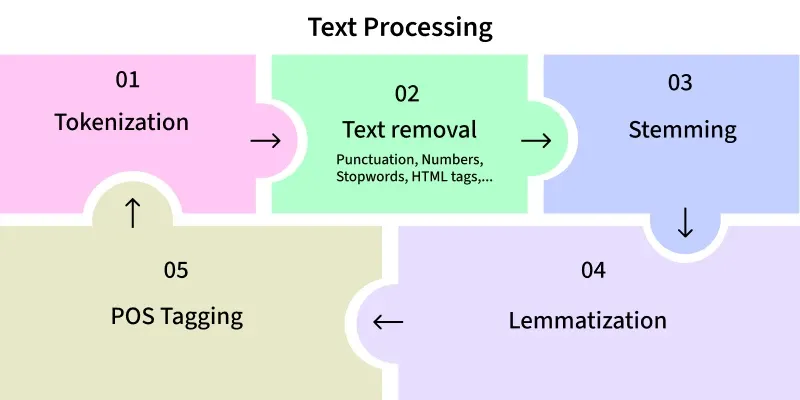
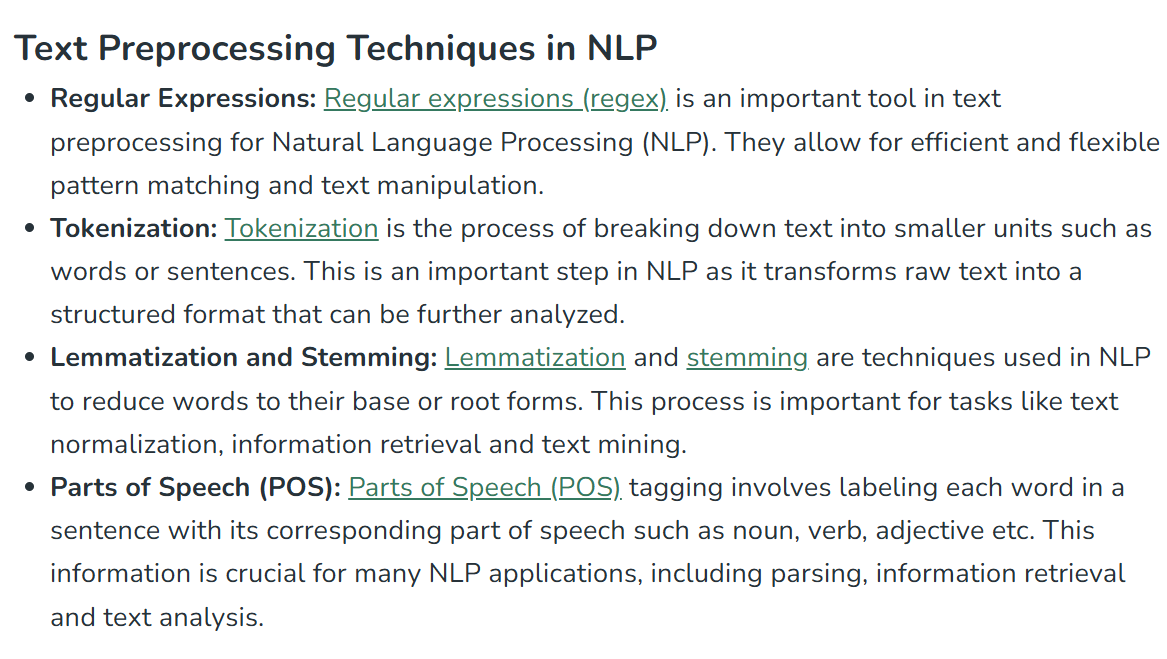

https://www.geeksforgeeks.org/nlp/text-preprocessing-for-nlp-tasks/

First we check the cleaned text

In [17]:
text = project_data.loc[0, "cleaned_text"]
print(text[:1000])

Delta Water Innovation Hub

Project ID: DWIH-2026-01
Start date: 2026-02-01
End date: 2028-12-31
Contact person: Dr. Lisa Vermeer

The Delta Water Innovation Hub project focuses on the reuse of treated water streams for agriculture and industrial applications in Zeeland. The project investigates how sensor systems, predictive models and decision-support dashboards can support sustainable water management in coastal regions.

The research is carried out by HZ Kenniscentrum Zeeuwse Samenleving and Water Technology. Researchers involved in the project include Dr. Lisa Vermeer, Tom de Bruin and Eva Jansen. The project is executed in collaboration with regional water authorities, agricultural partners and knowledge institutions.

The main goal is to reduce pressure on freshwater resources, improve water availability during drought periods and support circular water systems in the southwestern Netherlands.


Then we run the spacy library on the text

In [18]:
doc = nlp(text)

Then we tokenize the text

In [19]:
def preprocess_tokens(doc):
    tokens = []
    
    for token in doc:
        if (
            not token.is_stop and
            not token.is_punct and
            not token.is_space and
            token.is_alpha
        ):
            tokens.append(token.lemma_.lower())
    
    return tokens

tokens = preprocess_tokens(doc)
print(tokens[:50])

['delta', 'water', 'innovation', 'hub', 'project', 'id', 'start', 'date', 'end', 'date', 'contact', 'person', 'lisa', 'vermeer', 'delta', 'water', 'innovation', 'hub', 'project', 'focus', 'reuse', 'treat', 'water', 'stream', 'agriculture', 'industrial', 'application', 'zeeland', 'project', 'investigate', 'sensor', 'system', 'predictive', 'model', 'decision', 'support', 'dashboard', 'support', 'sustainable', 'water', 'management', 'coastal', 'region', 'research', 'carry', 'hz', 'kenniscentrum', 'zeeuwse', 'samenleving', 'water']


Now we segment the text

In [20]:
sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]
print(sentences[:5])

['Delta Water Innovation Hub\n\nProject ID: DWIH-2026-01\nStart date: 2026-02-01\nEnd date: 2028-12-31\nContact person: Dr. Lisa Vermeer\n\nThe Delta Water Innovation Hub project focuses on the reuse of treated water streams for agriculture and industrial applications in Zeeland.', 'The project investigates how sensor systems, predictive models and decision-support dashboards can support sustainable water management in coastal regions.', 'The research is carried out by HZ Kenniscentrum Zeeuwse Samenleving and Water Technology.', 'Researchers involved in the project include Dr. Lisa Vermeer, Tom de Bruin and Eva Jansen.', 'The project is executed in collaboration with regional water authorities, agricultural partners and knowledge institutions.']


Named entity extraction

In [21]:
entities = [(ent.text, ent.label_) for ent in doc.ents]
print(entities)

[('Delta Water Innovation Hub\n\nProject ID', 'ORG'), ('2026-02-01', 'DATE'), ('2028-12-31', 'DATE'), ('Lisa Vermeer', 'PERSON'), ('Zeeland', 'GPE'), ('HZ Kenniscentrum Zeeuwse Samenleving and Water Technology', 'ORG'), ('Lisa Vermeer', 'PERSON'), ('Tom de Bruin', 'PERSON'), ('Netherlands', 'GPE')]


In [22]:
silver_nlp_data = pd.DataFrame([{
    "document_id": project_data.loc[0, "document_id"],
    "cleaned_text": text,
    "tokens": tokens,
    "sentences": sentences,
    "entities": entities
}])

silver_nlp_data.head()

,document_id,cleaned_text,tokens,sentences,entities
0,doc_01,Delta Water Innovation Hub\n\nProject ID: DWIH...,"[delta, water, innovation, hub, project, id, s...",[Delta Water Innovation Hub\n\nProject ID: DWI...,"[(Delta Water Innovation Hub\n\nProject ID, OR..."


In [23]:
silver_nlp_data.to_json("../Data/silver/doc_01_silver_nlp.json", orient="records")